In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r'C:\Users\osaze\Desktop\nigerian_lending\data\processed\loans_cleaned.csv')
df.head()

,loan_amnt,term,int_rate,installment,grade,sub_grade,purpose,application_type,disbursement_method,initial_list_status,...,avg_cur_bal,total_bal_ex_mort,total_bc_limit,tot_cur_bal,tot_hi_cred_lim,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mths_since_recent_inq,default_flag,credit_age_years
0,35000,36,12.12,1164.51,B,B3,credit_card,Individual,Cash,f,...,20612.0,41223.0,4500.0,41223.0,49161.0,238.0,30.0,12.0,0,43.173169
1,5000,36,8.99,158.98,B,B1,debt_consolidation,Individual,Cash,f,...,1410.0,7050.0,5300.0,7050.0,14760.0,326.0,14.0,0.0,0,36.843258
2,23000,36,7.89,719.57,A,A5,debt_consolidation,Individual,Cash,w,...,15661.0,37604.0,11500.0,125287.0,152147.0,291.0,26.0,8.0,0,34.088980
3,12000,36,6.97,370.37,A,A3,credit_card,Individual,Cash,w,...,31245.0,104266.0,55400.0,406185.0,527519.0,411.0,46.0,1.0,0,44.339493
4,15000,36,7.69,467.91,A,A4,debt_consolidation,Individual,Cash,f,...,6001.0,27525.0,19400.0,96019.0,162247.0,191.0,1.0,1.0,0,27.425051


In [4]:
# perform an overview of the dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 57722 entries, 0 to 57721
Data columns (total 42 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   loan_amnt                   57722 non-null  int64  
 1   term                        57722 non-null  int64  
 2   int_rate                    57722 non-null  float64
 3   installment                 57722 non-null  float64
 4   grade                       57722 non-null  str    
 5   sub_grade                   57722 non-null  str    
 6   purpose                     57722 non-null  str    
 7   application_type            57722 non-null  str    
 8   disbursement_method         57722 non-null  str    
 9   initial_list_status         57722 non-null  str    
 10  emp_length                  54332 non-null  float64
 11  home_ownership              57722 non-null  str    
 12  annual_inc                  57721 non-null  float64
 13  verification_status         57722 non-null

In [5]:
# check the distribution of the numeric features
df.describe().T

,count,mean,std,min,25%,50%,75%,max
loan_amnt,57722.0,14406.563789,8703.196010,600.000000,8000.0000,12000.000000,20000.000000,4.000000e+04
term,57722.0,41.804788,10.277217,36.000000,36.0000,36.000000,36.000000,6.000000e+01
int_rate,57722.0,13.256172,4.750648,5.310000,9.7500,12.740000,16.010000,3.099000e+01
installment,57722.0,437.760109,261.468947,4.930000,247.7225,374.330000,580.137500,1.503890e+03
emp_length,54332.0,5.970570,3.689685,0.000000,3.0000,6.000000,10.000000,1.000000e+01
annual_inc,57721.0,76206.640654,70283.131772,0.000000,46000.0000,65000.000000,90000.000000,9.000000e+06
dti,57704.0,18.192983,9.562423,0.000000,11.7700,17.560000,23.980000,7.713100e+02
delinq_2yrs,57720.0,0.319335,0.885813,0.000000,0.0000,0.000000,0.000000,2.000000e+01
inq_last_6mths,57720.0,0.666147,0.957116,0.000000,0.0000,0.000000,1.000000,1.400000e+01
open_acc,57720.0,11.587093,5.451986,1.000000,8.0000,11.000000,14.000000,7.900000e+01


## Target Variable Analysis

In [19]:
# check the distribution of values in the target varaible to check for class imabalance
counts = df.default_flag.value_counts()
percentages = df.default_flag.value_counts(normalize=True)

combined_df = pd.concat([counts, percentages], axis=1, keys=['Count', 'Percentage'])
print(combined_df)

              Count  Percentage
default_flag                   
0             46067    0.798084
1             11655    0.201916


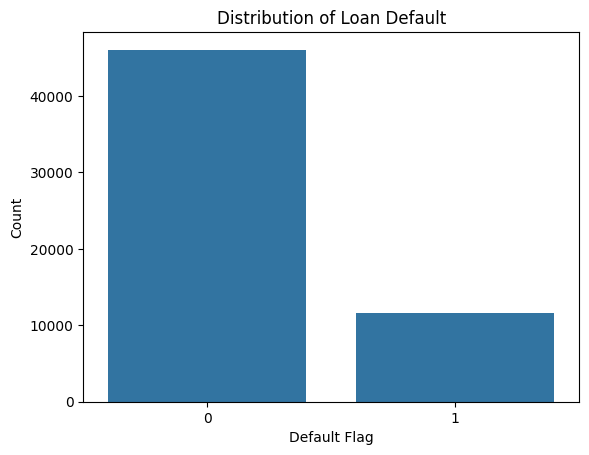

In [ ]:
sns.countplot(x="default_flag", data=df)
plt.xlabel("Default Flag")
plt.ylabel("Count")
plt.title("Distribution of Loan Default")
plt.show()

*The dataset shows class imbalance with approximately 20% default rate. Class weighting will be applied during model training to ensure the model does not bias toward the majority class.*

In [57]:
numeric_df = df.select_dtypes(include=["number"])

In [58]:
corr = numeric_df.corr().sort_values(by=['default_flag'], ascending=False)['default_flag']
corr

default_flag                  1.000000
int_rate                      0.263108
term                          0.178895
dti                           0.102779
percent_bc_gt_75              0.074565
bc_util                       0.071809
revol_util                    0.064254
loan_amnt                     0.063080
inq_last_6mths                0.059794
installment                   0.048363
pub_rec_bankruptcies          0.027250
pub_rec                       0.023439
open_acc                      0.021424
delinq_2yrs                   0.017888
collections_12_mths_ex_med    0.017127
delinq_amnt                   0.010091
tax_liens                     0.007478
chargeoff_within_12_mths      0.005351
acc_now_delinq               -0.000320
total_bal_ex_mort            -0.009482
revol_bal                    -0.015506
total_acc                    -0.016401
emp_length                   -0.017631
total_rev_hi_lim             -0.036728
annual_inc                   -0.042803
credit_age_years         

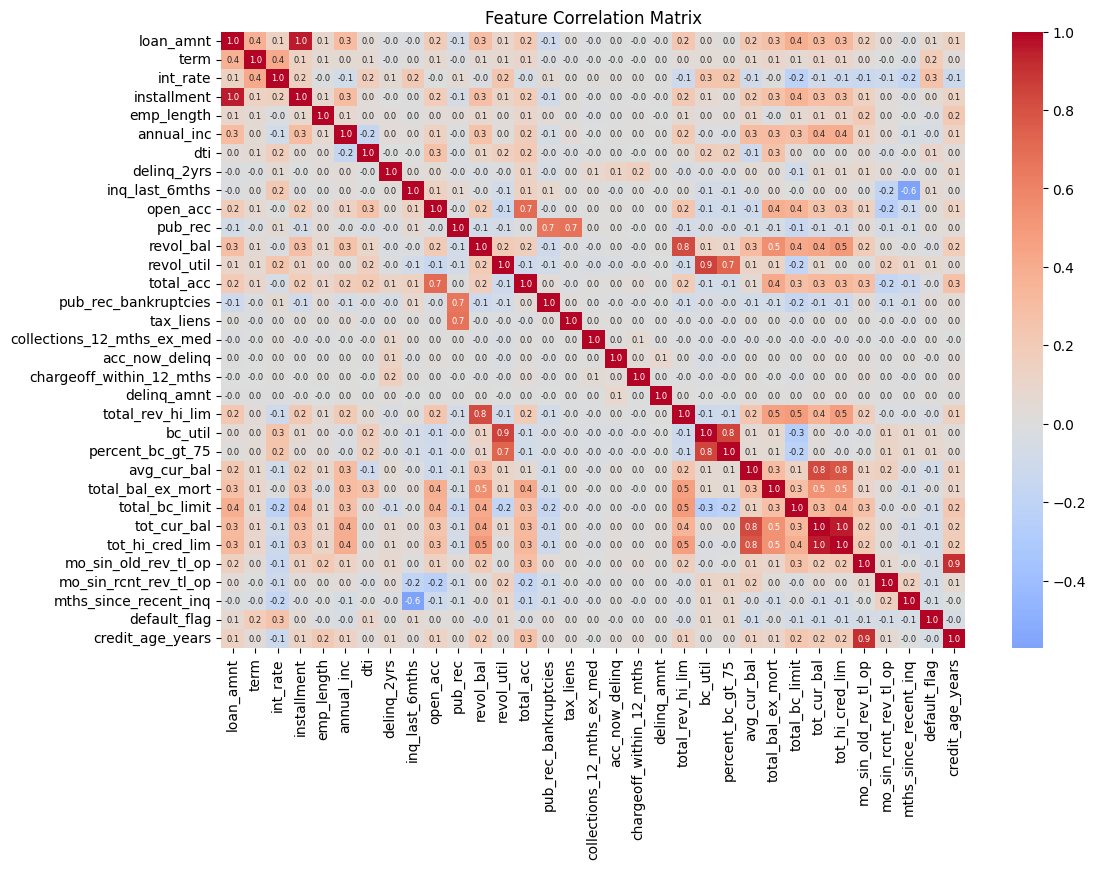

In [64]:
plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), cmap="coolwarm", center=0, annot_kws={"size": 6}, annot=True, fmt=".1f")
plt.title("Feature Correlation Matrix")
plt.show()

### Correlation Analysis

To better understand which numerical features are most related to loan default, a correlation analysis was performed between all numeric variables and the **`default_flag`** target variable. The correlation values indicate the strength and direction of the linear relationship between each feature and loan default.

From the results, **`int_rate`** (interest rate) shows the strongest positive correlation with loan default (~0.26). This suggests that loans with higher interest rates tend to have a higher probability of default. Other variables such as **`term`**, **`dti`** (debt-to-income ratio), and **`percent_bc_gt_75`** also show moderate positive correlations, indicating that longer loan terms and higher borrower debt levels may increase default risk.

On the other hand, some variables show weak negative correlations with the target. Features like **`annual_inc`**, **`credit_age_years`**, and **`total_bc_limit`** have slightly negative relationships with default, suggesting that borrowers with higher income, longer credit history, and higher credit limits tend to default less frequently.

To visually examine these relationships, a **correlation heatmap** was plotted. The heatmap provides a graphical representation of correlations across all numerical variables, making it easier to identify patterns and relationships in the dataset. The visualization confirms that most variables have relatively weak correlations with the target variable, which is common in financial risk datasets where default behavior is influenced by multiple interacting factors rather than a single dominant feature.

This correlation analysis helps highlight potentially important predictors that will be explored further during the modeling stage.
